# 사출성형기 라벨 데이터(`labeled_data.csv`) 분석

`04. Dataset_Molding/dataset/labeled_data.csv`(비식별화 원본 데이터)를 대상으로 **전처리 후** 데이터 조작과 시각화를 수행합니다.

**0. 데이터 전처리**: 분석 대상 장비/제품 필터링 → 불필요 컬럼 제거 → 결측치 처리 → 레이블 인코딩

**데이터 조작**
1. 컬럼추출 기초통계
2. 전체 목록(컬럼 구조 확인)
3. 그룹을 지어서 컬럼추출
4. 정렬(sort)

**시각화**: 4종 + 시각화별 인사이트(데이터 리터러시) 해설


In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.font_manager as fm
import seaborn as sns

sns.set_style('whitegrid')  # 스타일을 먼저 적용해야 아래 폰트 설정이 덮어써지지 않음

# 한글 깨짐 방지 (Windows): 폰트 파일을 직접 등록해야 폰트명이 안전하게 인식됨
_font_path = r'C:\Windows\Fonts\malgun.ttf'
fm.fontManager.addfont(_font_path)
_font_name = fm.FontProperties(fname=_font_path).get_name()
plt.rcParams['font.family'] = _font_name
plt.rcParams['axes.unicode_minus'] = False

df = pd.read_csv('04. Dataset_Molding/dataset/labeled_data.csv')
df.shape


(7996, 45)

## 0. 데이터 전처리

원본 `labeled_data.csv`에는 분석 대상이 아닌 장비·제품이 섞여 있고, 값이 전부 0으로 기록된 미사용 센서 컬럼도 포함되어 있습니다.
아래 순서로 전처리를 진행합니다.

1. **행 필터링**: 분석 대상 장비(`650톤-우진2호기`, EQUIP_CD=S14) + 주요 제품 4종(CN7 LH/RH, RG3 LH/RH)만 남김
2. **컬럼 제거**: 필터링 후 값이 전부 0인 센서 컬럼(미사용 센서), 필터링 후 값이 하나로 고정되는 식별/관리용 컬럼 제거
3. **결측치 처리**: `Reason`은 불량(N)일 때만 값이 채워지는 컬럼이므로, 결측(NaN)을 '해당없음'(=양품)으로 명시적으로 채움
4. **레이블 인코딩**: `PassOrFail`을 문자열 `'Y'/'N'` → 정수 `0(양품)/1(불량)`으로 변환


In [2]:
# 0-1. 분석 대상 장비/제품 필터링
main_parts = [
    "CN7 W/S SIDE MLD'G RH", "CN7 W/S SIDE MLD'G LH",
    "RG3 MOLD'G W/SHLD, LH", "RG3 MOLD'G W/SHLD, RH",
]

rows_before = len(df)
df = df[(df['EQUIP_CD'] == 'S14') & (df['PART_NAME'].isin(main_parts))].copy()
print(f'행 필터링: {rows_before:,}건 -> {len(df):,}건 '
      f'(장비 650톤-우진2호기 + 주요 제품 4종만 사용, {rows_before - len(df)}건 제외)')


행 필터링: 7,996건 -> 7,992건 (장비 650톤-우진2호기 + 주요 제품 4종만 사용, 4건 제외)


In [3]:
# 0-2. 무의미한 컬럼 제거: 전부 0인 센서 컬럼 + 필터링 후 값이 고정되는 식별/관리용 컬럼
zero_cols = [
    c for c in df.columns
    if pd.api.types.is_numeric_dtype(df[c]) and (df[c] == 0).all()
]
const_cols = [
    c for c in ['_id', 'EQUIP_CD', 'EQUIP_NAME', 'PART_FACT_PLAN_DATE', 'PART_FACT_SERIAL']
    if c in df.columns
]

drop_cols = sorted(set(zero_cols + const_cols))
print(f'제거 컬럼 ({len(drop_cols)}개):', drop_cols)

df = df.drop(columns=drop_cols)
print(f'컬럼 수: 45 -> {df.shape[1]}')


제거 컬럼 (16개): ['Barrel_Temperature_7', 'EQUIP_CD', 'EQUIP_NAME', 'Mold_Temperature_1', 'Mold_Temperature_10', 'Mold_Temperature_11', 'Mold_Temperature_12', 'Mold_Temperature_2', 'Mold_Temperature_5', 'Mold_Temperature_6', 'Mold_Temperature_7', 'Mold_Temperature_8', 'Mold_Temperature_9', 'PART_FACT_PLAN_DATE', 'PART_FACT_SERIAL', '_id']
컬럼 수: 45 -> 29


In [4]:
# 0-3. 결측치 처리 + 0-4. 레이블 인코딩
df['Reason'] = df['Reason'].fillna('해당없음')

df['PassOrFail'] = df['PassOrFail'].map({'Y': 0, 'N': 1})

print('PassOrFail 인코딩 결과 (0=양품, 1=불량):')
print(df['PassOrFail'].value_counts())
df.head()


PassOrFail 인코딩 결과 (0=양품, 1=불량):
PassOrFail
0    7921
1      71
Name: count, dtype: int64


,TimeStamp,PART_NAME,PassOrFail,Reason,Injection_Time,Filling_Time,Plasticizing_Time,Cycle_Time,Clamp_Close_Time,Cushion_Position,...,Average_Back_Pressure,Barrel_Temperature_1,Barrel_Temperature_2,Barrel_Temperature_3,Barrel_Temperature_4,Barrel_Temperature_5,Barrel_Temperature_6,Hopper_Temperature,Mold_Temperature_3,Mold_Temperature_4
0,2020-10-16 04:57:47,CN7 W/S SIDE MLD'G RH,0,해당없음,9.59,4.47,16.92,59.520000,7.13,653.409973,...,59.299999,276.500000,274.700012,274.799988,269.200012,255.000000,229.699997,66.300003,24.799999,27.5
1,2020-10-16 04:58:48,CN7 W/S SIDE MLD'G RH,0,해당없음,9.60,4.48,16.91,59.580002,7.13,653.409973,...,59.299999,276.200012,275.500000,275.299988,270.799988,254.699997,229.500000,67.199997,24.799999,27.6
2,2020-10-16 04:58:48,CN7 W/S SIDE MLD'G LH,0,해당없음,9.60,4.48,16.91,59.580002,7.13,653.409973,...,59.299999,276.200012,275.500000,275.299988,270.799988,254.699997,229.500000,67.199997,24.799999,27.6
3,2020-10-16 04:59:48,CN7 W/S SIDE MLD'G LH,0,해당없음,9.59,4.48,16.91,59.560001,7.13,653.419983,...,59.299999,276.500000,275.000000,275.399994,271.100006,254.899994,230.000000,66.900002,25.000000,27.6
4,2020-10-16 04:59:48,CN7 W/S SIDE MLD'G RH,0,해당없음,9.59,4.48,16.91,59.560001,7.13,653.419983,...,59.299999,276.500000,275.000000,275.399994,271.100006,254.899994,230.000000,66.900002,25.000000,27.6


## 1. 데이터 개요

In [5]:
print('행/열:', df.shape)
df.head()


행/열: (7992, 29)


,TimeStamp,PART_NAME,PassOrFail,Reason,Injection_Time,Filling_Time,Plasticizing_Time,Cycle_Time,Clamp_Close_Time,Cushion_Position,...,Average_Back_Pressure,Barrel_Temperature_1,Barrel_Temperature_2,Barrel_Temperature_3,Barrel_Temperature_4,Barrel_Temperature_5,Barrel_Temperature_6,Hopper_Temperature,Mold_Temperature_3,Mold_Temperature_4
0,2020-10-16 04:57:47,CN7 W/S SIDE MLD'G RH,0,해당없음,9.59,4.47,16.92,59.520000,7.13,653.409973,...,59.299999,276.500000,274.700012,274.799988,269.200012,255.000000,229.699997,66.300003,24.799999,27.5
1,2020-10-16 04:58:48,CN7 W/S SIDE MLD'G RH,0,해당없음,9.60,4.48,16.91,59.580002,7.13,653.409973,...,59.299999,276.200012,275.500000,275.299988,270.799988,254.699997,229.500000,67.199997,24.799999,27.6
2,2020-10-16 04:58:48,CN7 W/S SIDE MLD'G LH,0,해당없음,9.60,4.48,16.91,59.580002,7.13,653.409973,...,59.299999,276.200012,275.500000,275.299988,270.799988,254.699997,229.500000,67.199997,24.799999,27.6
3,2020-10-16 04:59:48,CN7 W/S SIDE MLD'G LH,0,해당없음,9.59,4.48,16.91,59.560001,7.13,653.419983,...,59.299999,276.500000,275.000000,275.399994,271.100006,254.899994,230.000000,66.900002,25.000000,27.6
4,2020-10-16 04:59:48,CN7 W/S SIDE MLD'G RH,0,해당없음,9.59,4.48,16.91,59.560001,7.13,653.419983,...,59.299999,276.500000,275.000000,275.399994,271.100006,254.899994,230.000000,66.900002,25.000000,27.6


## 2. 컬럼추출 기초통계

공정 관련 주요 수치형 컬럼만 추출해 기초통계량을 확인합니다.
(값이 전부 0이던 미사용 센서 컬럼은 0단계 전처리에서 이미 제거했습니다.)


In [6]:
key_cols = [
    'Injection_Time', 'Filling_Time', 'Plasticizing_Time', 'Cycle_Time',
    'Max_Injection_Speed', 'Max_Injection_Pressure', 'Max_Back_Pressure',
    'Barrel_Temperature_1', 'Mold_Temperature_3', 'Mold_Temperature_4',
]

df[key_cols].describe().T


,count,mean,std,min,25%,50%,75%,max
Injection_Time,7992.0,8.241201,3.105195,1.050000,9.520000,9.560000,9.590000,13.390000
Filling_Time,7992.0,3.896510,1.284693,0.930000,4.400000,4.440000,4.470000,8.270000
Plasticizing_Time,7992.0,16.209600,1.439560,12.800000,16.580000,16.799999,16.889999,21.100000
Cycle_Time,7992.0,59.898590,0.878291,58.840000,59.520000,59.520000,59.560001,64.349998
Max_Injection_Speed,7992.0,66.939264,26.455866,38.500000,55.200001,55.599998,56.099998,128.500000
Max_Injection_Pressure,7992.0,142.179555,1.836804,140.699997,141.800003,142.000000,142.199997,169.100006
Max_Back_Pressure,7992.0,40.716216,6.854524,21.700001,37.700001,38.000000,38.400002,75.199997
Barrel_Temperature_1,7992.0,277.534597,4.208320,244.699997,275.899994,276.200012,276.600006,287.100006
Mold_Temperature_3,7992.0,22.151589,1.123329,19.100000,21.400000,22.000000,22.900000,25.299999
Mold_Temperature_4,7992.0,23.528741,1.304764,20.600000,22.700001,23.400000,24.200001,27.799999


## 3. 전체 목록

데이터셋에 존재하는 전체 컬럼과 타입을 확인합니다.


In [7]:
print(f'전체 컬럼 수: {len(df.columns)}')
print(list(df.columns))
df.info()


전체 컬럼 수: 29
['TimeStamp', 'PART_NAME', 'PassOrFail', 'Reason', 'Injection_Time', 'Filling_Time', 'Plasticizing_Time', 'Cycle_Time', 'Clamp_Close_Time', 'Cushion_Position', 'Switch_Over_Position', 'Plasticizing_Position', 'Clamp_Open_Position', 'Max_Injection_Speed', 'Max_Screw_RPM', 'Average_Screw_RPM', 'Max_Injection_Pressure', 'Max_Switch_Over_Pressure', 'Max_Back_Pressure', 'Average_Back_Pressure', 'Barrel_Temperature_1', 'Barrel_Temperature_2', 'Barrel_Temperature_3', 'Barrel_Temperature_4', 'Barrel_Temperature_5', 'Barrel_Temperature_6', 'Hopper_Temperature', 'Mold_Temperature_3', 'Mold_Temperature_4']
<class 'pandas.DataFrame'>
Index: 7992 entries, 0 to 7995
Data columns (total 29 columns):
 #   Column                    Non-Null Count  Dtype  
---  ------                    --------------  -----  
 0   TimeStamp                 7992 non-null   str    
 1   PART_NAME                 7992 non-null   str    
 2   PassOrFail                7992 non-null   int64  
 3   Reason        

## 4. 그룹을 지어서 컬럼추출 (Groupby)

제품(`PART_NAME`) x 양불(`PassOrFail`, 0=양품/1=불량) 그룹별로 주요 공정변수의 평균을 비교합니다.


In [8]:
group_stats = (
    df.groupby(['PART_NAME', 'PassOrFail'])[key_cols]
    .mean()
    .round(2)
)
group_stats


Injection_Time  Filling_Time  \
PART_NAME             PassOrFail                                 
CN7 W/S SIDE MLD'G LH 0                     9.57          4.44   
                      1                    10.49          5.38   
CN7 W/S SIDE MLD'G RH 0                     9.58          4.44   
                      1                    10.21          5.10   
RG3 MOLD'G W/SHLD, LH 0                     1.06          0.94   
                      1                     1.07          0.95   
RG3 MOLD'G W/SHLD, RH 0                     1.06          0.94   
                      1                     1.06          0.94   

                                  Plasticizing_Time  Cycle_Time  \
PART_NAME             PassOrFail                                  
CN7 W/S SIDE MLD'G LH 0                       16.82       59.54   
                      1                       16.71       60.28   
CN7 W/S SIDE MLD'G RH 0                       16.82       59.55   
                      1                       16.81       60.05   
RG3 MOLD'G W/SHLD, LH 0                       12.93       61.77   
                      1                       13.14       61.78   
RG3 MOLD'G W/SHLD, RH 0                       12.93       61.77   
                      1                       12.95       61.79   

                                  Max_Injection_Speed  Max_Injection_Pressure  \
PART_NAME             PassOrFail                                                
CN7 W/S SIDE MLD'G LH 0                         55.54                  142.07   
                      1                         50.70                  143.52   
CN7 W/S SIDE MLD'G RH 0                         55.55                  142.10   
                      1                         52.23                  142.95   
RG3 MOLD'G W/SHLD, LH 0                        128.17                  142.65   
                      1                        127.26                  143.30   
RG3 MOLD'G W/SHLD, RH 0                        128.17                  142.66   
                      1                        128.13                  142.68   

                                  Max_Back_Pressure  Barrel_Temperature_1  \
PART_NAME             PassOrFail                                            
CN7 W/S SIDE MLD'G LH 0                       37.82                275.98   
                      1                       44.37                276.14   
CN7 W/S SIDE MLD'G RH 0                       37.80                275.95   
                      1                       42.12                276.05   
RG3 MOLD'G W/SHLD, LH 0                       56.11                285.95   
                      1                       57.78                285.78   
RG3 MOLD'G W/SHLD, RH 0                       56.13                285.96   
                      1                       56.19                285.90   

                                  Mold_Temperature_3  Mold_Temperature_4  
PART_NAME             PassOrFail                                          
CN7 W/S SIDE MLD'G LH 0                        22.07               23.47  
                      1                        21.89               23.56  
CN7 W/S SIDE MLD'G RH 0                        22.07               23.46  
                      1                        23.11               25.13  
RG3 MOLD'G W/SHLD, LH 0                        22.57               23.82  
                      1                        22.46               24.36  
RG3 MOLD'G W/SHLD, RH 0                        22.57               23.83  
                      1                        22.51               23.78

## 5. 정렬 (Sort)

제품별 **불량률**을 계산해 **내림차순**으로 정렬합니다.
불량 개선 활동은 불량률이 높은 제품부터 우선 점검하는 것이 효과적이므로 오름차순이 아닌 내림차순을 사용합니다.


In [9]:
defect_rate_by_part = (
    df.groupby('PART_NAME')['PassOrFail']
    .apply(lambda s: (s == 1).mean())
    .sort_values(ascending=False)
    .rename('defect_rate')
)
defect_rate_by_part


PART_NAME
RG3 MOLD'G W/SHLD, RH    0.042994
RG3 MOLD'G W/SHLD, LH    0.007962
CN7 W/S SIDE MLD'G RH    0.006823
CN7 W/S SIDE MLD'G LH    0.004755
Name: defect_rate, dtype: float64

## 6. 시각화 + 데이터 리터러시

### 시각화 1) 양품/불량 분포 (클래스 불균형 확인)

C:\Users\한국전파진흥협회\AppData\Local\Temp\ipykernel_10544\1735353083.py:2: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  ax = sns.countplot(data=df, x='PassOrFail', order=[0, 1], palette=['#4C72B0', '#C44E52'])
C:\Users\한국전파진흥협회\AppData\Local\Temp\ipykernel_10544\1735353083.py:3: UserWarning: set_ticklabels() should only be used with a fixed number of ticks, i.e. after set_ticks() or using a FixedLocator. Otherwise, ticks may be mislabeled.
  ax.set_xticklabels(['양품(0)', '불량(1)'])


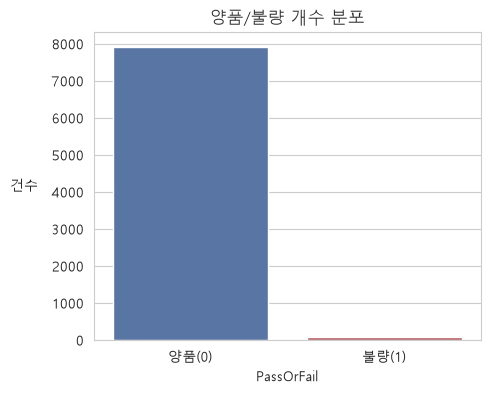

In [10]:
plt.figure(figsize=(5, 4))
ax = sns.countplot(data=df, x='PassOrFail', order=[0, 1], palette=['#4C72B0', '#C44E52'])
ax.set_xticklabels(['양품(0)', '불량(1)'])
plt.title('양품/불량 개수 분포')
plt.xlabel('PassOrFail')
plt.ylabel('건수', rotation=0, labelpad=20, va='center')  # 회전 시 한글 글리프가 깨져 가로쓰기로 표기
plt.show()


**리터러시**: 전처리 후 7,992건 중 불량은 71건(0.89%)에 불과해 극심한 클래스 불균형이 존재합니다.
정확도(accuracy)만으로 모델을 평가하면 '전부 양품'이라고만 예측해도 99%가 넘는 정확도가 나오므로,
재현율(recall)·F1-score 등 불균형에 강건한 지표로 평가해야 합니다.
가이드북에서 오버/언더샘플링이나 이상탐지(오토인코더) 접근을 택한 이유이기도 합니다.


### 시각화 2) 제품별 불량 건수 (정렬 막대그래프)

C:\Users\한국전파진흥협회\AppData\Local\Temp\ipykernel_10544\441686290.py:8: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x=defect_count_by_part.values, y=defect_count_by_part.index, palette='Reds_r')


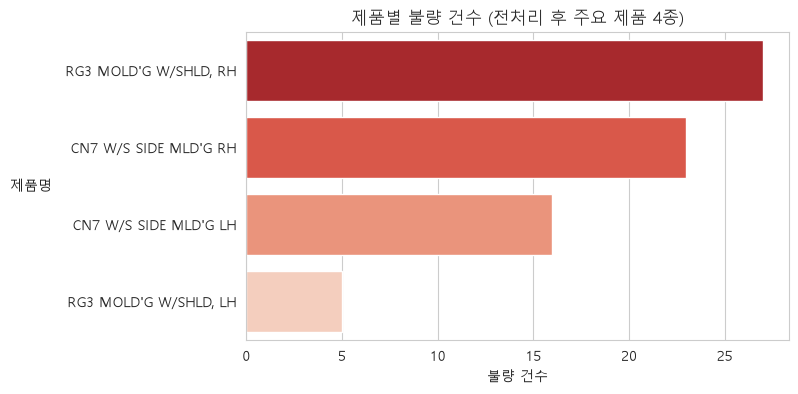

In [11]:
defect_count_by_part = (
    df.groupby('PART_NAME')['PassOrFail']
    .apply(lambda s: (s == 1).sum())
    .sort_values(ascending=False)
)

plt.figure(figsize=(7, 4))
sns.barplot(x=defect_count_by_part.values, y=defect_count_by_part.index, palette='Reds_r')
plt.title('제품별 불량 건수 (전처리 후 주요 제품 4종)')
plt.xlabel('불량 건수')
plt.ylabel('제품명', rotation=0, labelpad=25, va='center')  # 회전 시 한글 글리프가 깨져 가로쓰기로 표기
plt.show()


**리터러시**: `RG3 MOLD'G W/SHLD, RH`는 생산량이 628건으로 CN7 계열(3,300여 건)의 5분의 1도 안 되지만,
불량 건수는 27건으로 전체 71건의 약 38%를 차지하며 절대 건수 기준으로도 1위입니다. 불량률로 보면 4.30%로
CN7 계열(0.48~0.68%)의 6~9배에 달합니다. 즉 생산량이 많은 CN7이 아니라 **RG3 RH 공정을 최우선으로 점검**해야
불량을 효율적으로 줄일 수 있다는 결론이 나옵니다.


### 시각화 3) 주요 공정변수 상관관계 히트맵

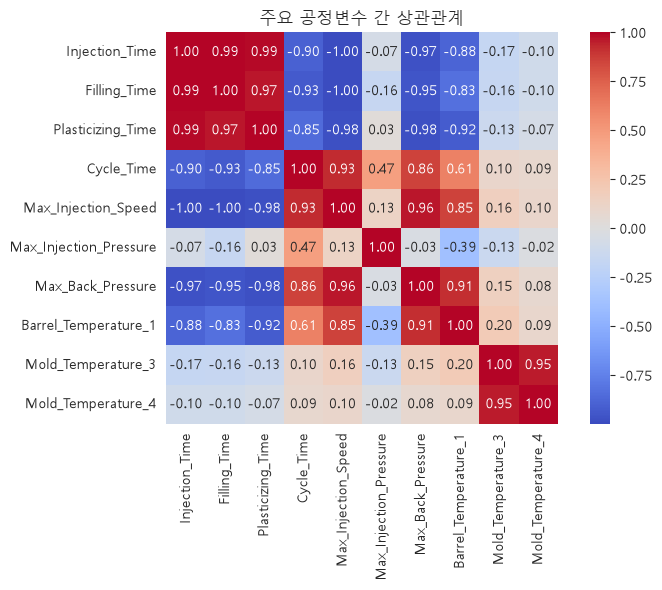

In [12]:
plt.figure(figsize=(8, 6))
corr = df[key_cols].corr()
sns.heatmap(corr, annot=True, fmt='.2f', cmap='coolwarm', center=0, square=True)
plt.title('주요 공정변수 간 상관관계')
plt.tight_layout()
plt.show()


**리터러시**: `Injection_Time`과 `Max_Injection_Speed`는 상관계수 -1.00에 가까운 거의 완벽한 음의 상관관계를
보입니다. 사출속도가 빠를수록 충전 시간이 짧아지는 물리 법칙이 그대로 데이터에 반영된 것으로, 두 변수를 모델에
함께 넣으면 다중공선성(multicollinearity) 문제가 생길 수 있어 회귀 계열 모델에서는 하나만 선택하는 것이 안전합니다.
`Mold_Temperature_3`과 `Mold_Temperature_4`도 상관계수 0.96으로 매우 유사하게 움직여, 같은 금형 냉각 계통에서
함께 제어되고 있음을 시사합니다.


### 시각화 4) 양품/불량별 최대 사출속도 비교 (Boxplot)

C:\Users\한국전파진흥협회\AppData\Local\Temp\ipykernel_10544\2497241136.py:2: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  ax = sns.boxplot(data=df, x='PassOrFail', y='Max_Injection_Speed', order=[0, 1],
C:\Users\한국전파진흥협회\AppData\Local\Temp\ipykernel_10544\2497241136.py:4: UserWarning: set_ticklabels() should only be used with a fixed number of ticks, i.e. after set_ticks() or using a FixedLocator. Otherwise, ticks may be mislabeled.
  ax.set_xticklabels(['양품(0)', '불량(1)'])


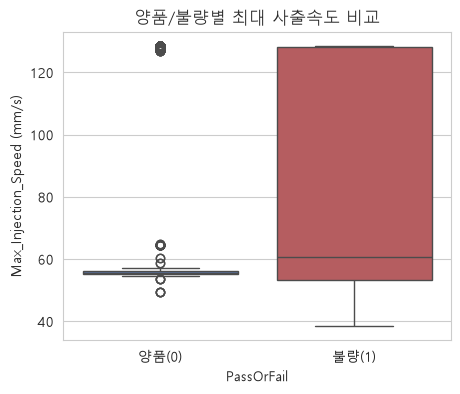

In [13]:
plt.figure(figsize=(5, 4))
ax = sns.boxplot(data=df, x='PassOrFail', y='Max_Injection_Speed', order=[0, 1],
                  palette=['#4C72B0', '#C44E52'])
ax.set_xticklabels(['양품(0)', '불량(1)'])
plt.title('양품/불량별 최대 사출속도 비교')
plt.xlabel('PassOrFail')
plt.ylabel('Max_Injection_Speed (mm/s)')
plt.show()


**리터러시**: 불량(N) 그룹의 평균 최대 사출속도는 86.0mm/s로 양품(Y) 그룹의 66.8mm/s보다 뚜렷이 높고,
박스플롯에서도 두 그룹의 중앙값과 분포 구간이 눈에 띄게 갈립니다. 과도하게 빠른 사출속도가 쇼트숏·플래시 등의
불량과 연관될 수 있음을 시사하며, 이후 분류/이상탐지 모델에서 `Max_Injection_Speed`가 유의미한 판별 변수가 될
가능성이 높습니다. 다만 상관관계일 뿐 인과관계는 아니므로, 원인을 확정하려면 추가적인 공정 실험이 필요합니다.


## 요약

- 전처리: 분석 대상 장비/제품(4종)만 남기고, 미사용 센서·식별용 컬럼 제거, 라벨 인코딩(Y/N → 0/1) 완료
- 전체 불량률은 **0.89%**로 데이터 불균형이 매우 심함 (양품 7,921 : 불량 71, 전처리 후 7,992건 기준)
- 불량은 `RG3 MOLD'G W/SHLD, RH`에 집중 (불량률 4.30%, 전체 불량의 약 38%) → 우선 점검 대상
- `Injection_Time`↔`Max_Injection_Speed`는 상관계수 -1.00으로 강한 다중공선성 → 모델링 시 변수 선택 주의
- `Max_Injection_Speed`가 양품/불량 그룹 간 뚜렷한 차이를 보여 불량 예측의 핵심 후보 변수로 판단됨
